Probabilistic Reasoning


In [ ]:
pip install matplotlib seaborn

In [ ]:
# Required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-deep')
%matplotlib inline

Example 1: Coin Flip Simulation

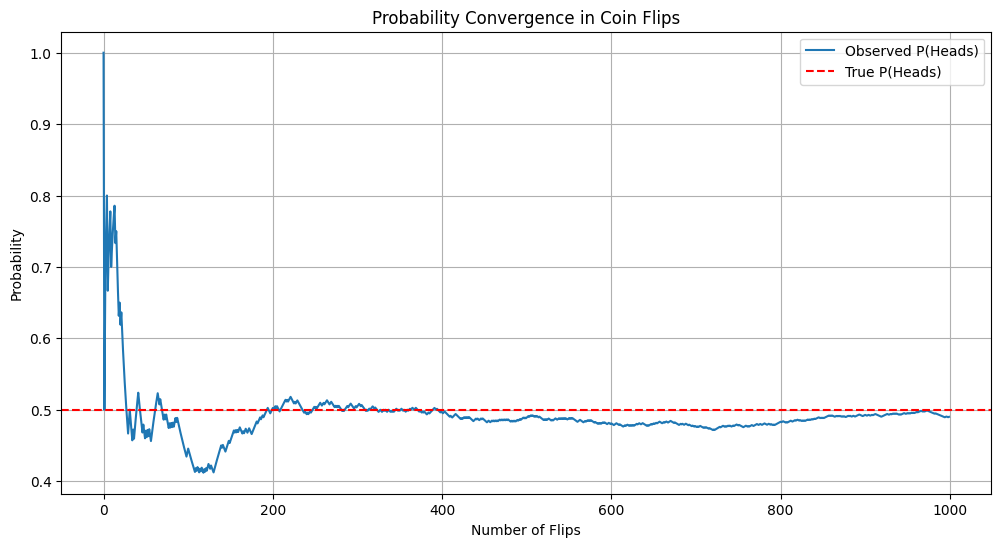

After 1000 flips:
Observed P(Heads) = 0.490
Expected P(Heads) = 0.500


In [ ]:
def coin_flip_simulation(n_flips=1000):
    """
    Simulate coin flips and demonstrate probability convergence

    Parameters:
        n_flips: Number of coin flips to simulate
    """
    # Simulate coin flips
    flips = np.random.choice(['Heads', 'Tails'], n_flips)

    # Calculate running probability of heads
    heads_count = np.cumsum(flips == 'Heads')
    running_prob = heads_count / np.arange(1, n_flips + 1)

    # Create visualization
    plt.figure(figsize=(12, 6))
    plt.plot(running_prob, label='Observed P(Heads)')
    plt.axhline(y=0.5, color='r', linestyle='--',
                label='True P(Heads)')
    plt.xlabel('Number of Flips')
    plt.ylabel('Probability')
    plt.title('Probability Convergence in Coin Flips')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print final statistics
    final_prob = running_prob[-1]
    print(f"After {n_flips} flips:")
    print(f"Observed P(Heads) = {final_prob:.3f}")
    print(f"Expected P(Heads) = 0.500")

# Run simulation
coin_flip_simulation()

Example 2: Die Rolling Simulation


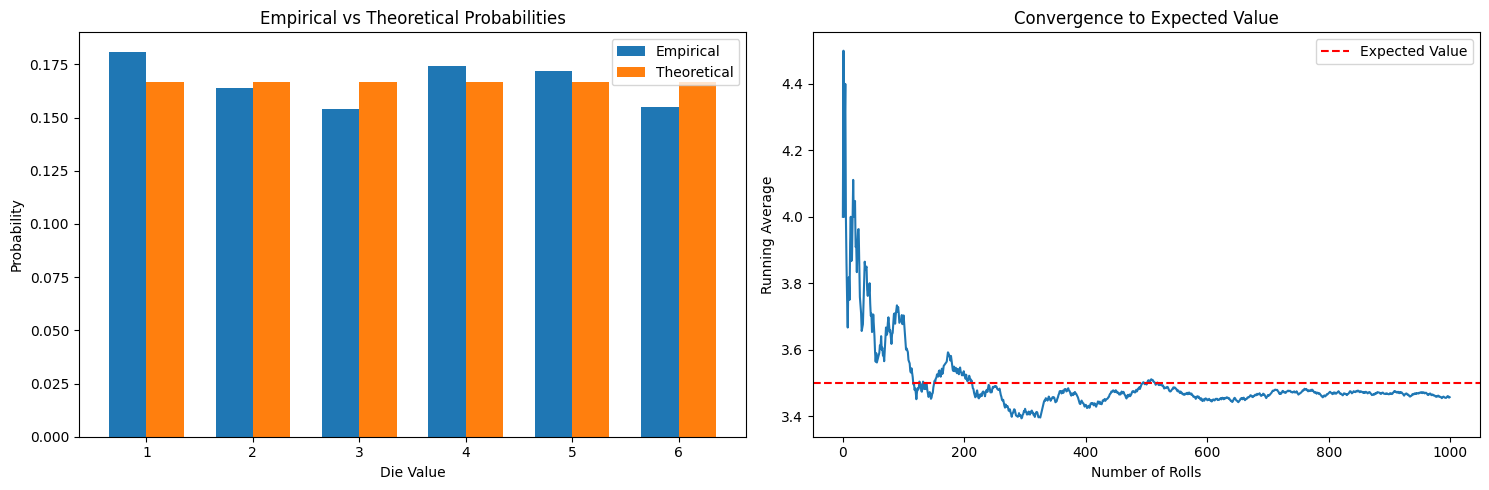

Empirical probabilities: [0.181 0.164 0.154 0.174 0.172 0.155]


In [ ]:
def simulate_die_rolls(num_rolls=1000):
    """Simulate multiple die rolls and analyze probabilities"""
    # Simulate rolls
    rolls = np.random.randint(1, 7, num_rolls)

    # Calculate empirical probabilities
    unique, counts = np.unique(rolls, return_counts=True)
    empirical_probs = counts / num_rolls

    # Theoretical probabilities
    theoretical_probs = np.ones(6) / 6

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot comparing empirical vs theoretical
    x = np.arange(1, 7)
    width = 0.35
    ax1.bar(x - width/2, empirical_probs, width, label='Empirical')
    ax1.bar(x + width/2, theoretical_probs, width, label='Theoretical')
    ax1.set_xlabel('Die Value')
    ax1.set_ylabel('Probability')
    ax1.set_title('Empirical vs Theoretical Probabilities')
    ax1.legend()

    # Convergence plot
    cumulative_means = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)
    ax2.plot(cumulative_means)
    ax2.axhline(y=3.5, color='r', linestyle='--', label='Expected Value')
    ax2.set_xlabel('Number of Rolls')
    ax2.set_ylabel('Running Average')
    ax2.set_title('Convergence to Expected Value')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return empirical_probs

# Run simulation
probs = simulate_die_rolls()
print("Empirical probabilities:", probs)

# **Random Variables**

Example 3: Die Roll Distribution

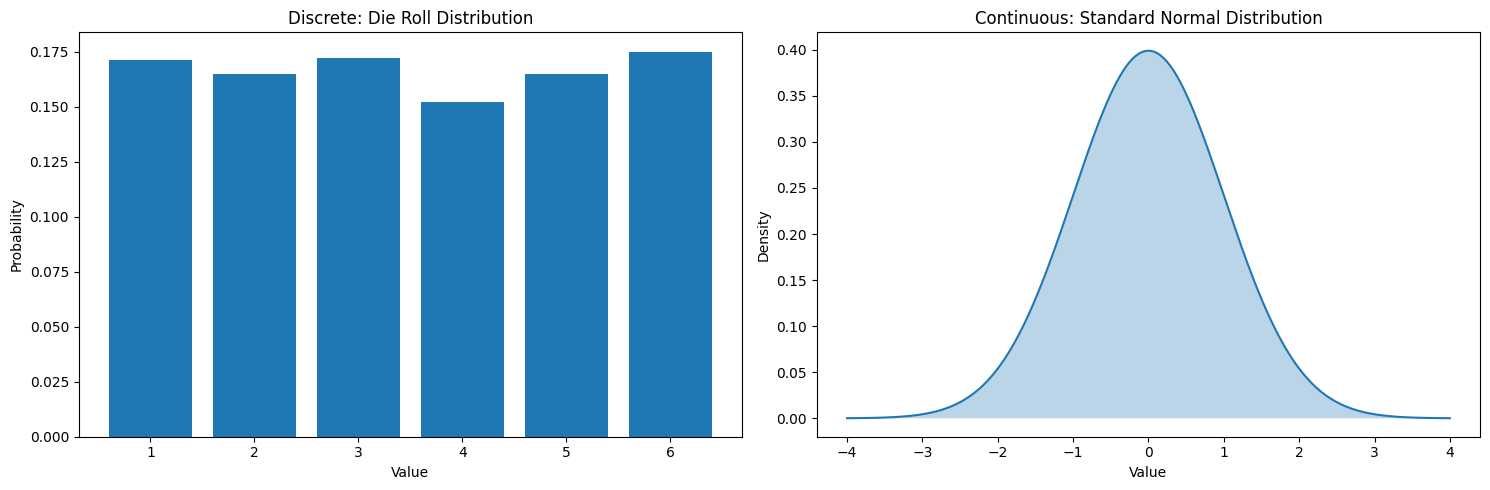

In [ ]:
def demonstrate_distributions():
    """Show examples of discrete and continuous distributions"""
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Discrete: Die rolls
    n_rolls = 1000
    rolls = np.random.randint(1, 7, n_rolls)
    values, counts = np.unique(rolls, return_counts=True)
    ax1.bar(values, counts/n_rolls)
    ax1.set_title('Discrete: Die Roll Distribution')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Probability')

    # Continuous: Normal distribution
    x = np.linspace(-4, 4, 1000)
    ax2.plot(x, stats.norm.pdf(x, 0, 1))
    ax2.fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.3)
    ax2.set_title('Continuous: Standard Normal Distribution')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('Density')

    plt.tight_layout()
    plt.show()

# Display distributions
demonstrate_distributions()

# **Conditional Probability**

Example 4: Card Drawing




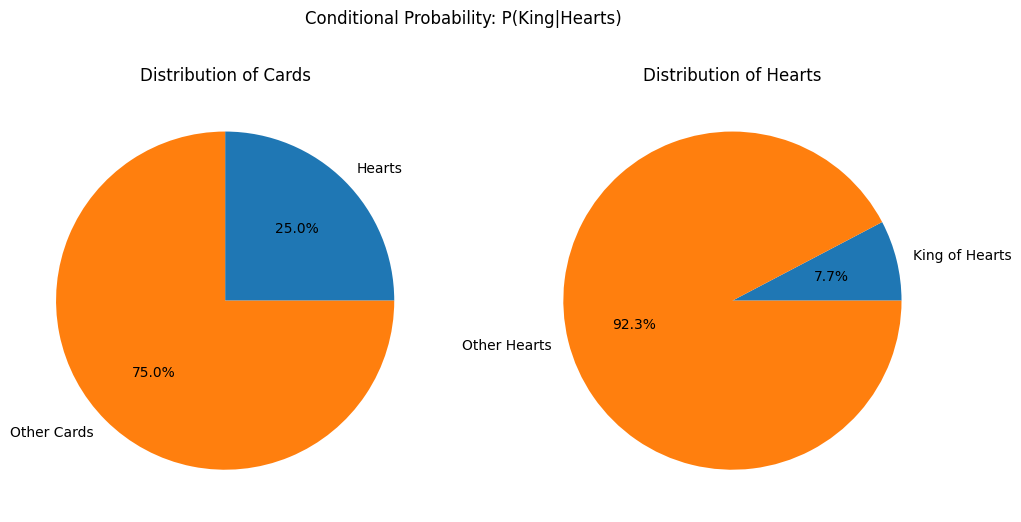

P(King|Hearts) = 0.077 or about 7.7%


In [ ]:
def card_example():
    """Demonstrate conditional probability with card drawing"""
    # Create a deck of cards
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K', 'A']

    # Calculate probabilities
    total_cards = len(suits) * len(ranks)  # 52
    hearts = len(ranks)  # 13
    king_of_hearts = 1

    # Conditional probability
    p_king_given_heart = king_of_hearts / hearts

    # Visualization
    plt.figure(figsize=(12, 6))

    # First subplot: All cards
    plt.subplot(1, 2, 1)
    plt.pie([hearts, total_cards-hearts], labels=['Hearts', 'Other Cards'],
            autopct='%1.1f%%')
    plt.title('Distribution of Cards')

    # Second subplot: Hearts only
    plt.subplot(1, 2, 2)
    plt.pie([1, hearts-1], labels=['King of Hearts', 'Other Hearts'],
            autopct='%1.1f%%')
    plt.title('Distribution of Hearts')

    plt.suptitle('Conditional Probability: P(King|Hearts)')
    plt.show()

    print(f"P(King|Hearts) = {p_king_given_heart:.3f} or about {p_king_given_heart:.1%}")

# Run example
card_example()

Example 5: Medical Testing

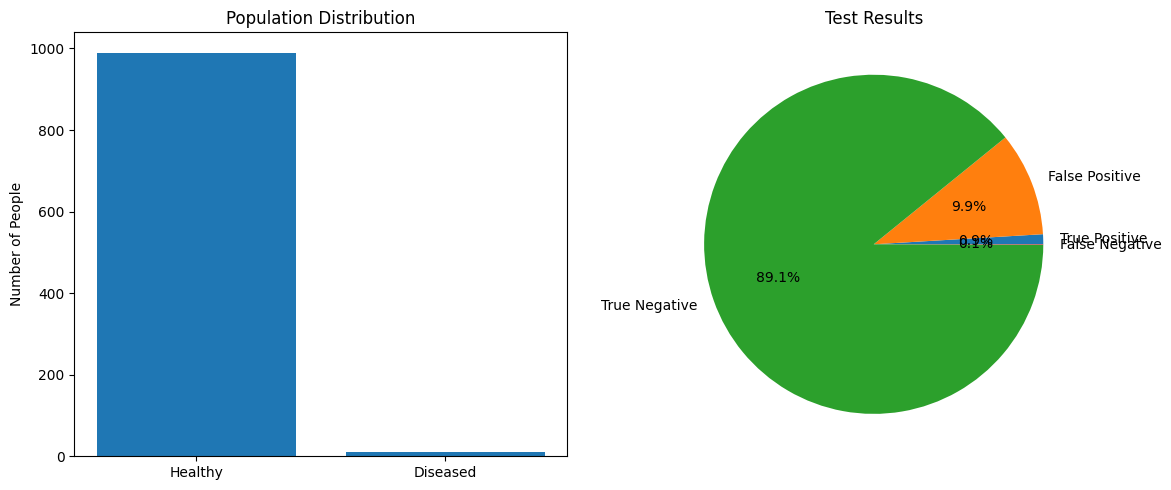

If test is positive, probability of disease: 8.8%


In [ ]:
def medical_test_example():
    """Demonstrate conditional probability in medical testing"""
    # Parameters
    prevalence = 0.01  # P(D)
    sensitivity = 0.95  # P(+|D)
    specificity = 0.90  # P(-|H)

    # Calculate P(D|+) using Bayes' Rule
    p_positive = (sensitivity * prevalence) + \
                ((1 - specificity) * (1 - prevalence))
    p_disease_given_positive = (sensitivity * prevalence) / p_positive

    # Visualization for 1000 people
    population = 1000
    diseased = population * prevalence
    healthy = population - diseased

    true_pos = diseased * sensitivity
    false_pos = healthy * (1 - specificity)
    true_neg = healthy * specificity
    false_neg = diseased * (1 - sensitivity)

    # Create visualization
    plt.figure(figsize=(12, 5))

    # Population breakdown
    plt.subplot(1, 2, 1)
    plt.bar(['Healthy', 'Diseased'], [healthy, diseased])
    plt.title('Population Distribution')
    plt.ylabel('Number of People')

    # Test results breakdown
    plt.subplot(1, 2, 2)
    results = [true_pos, false_pos, true_neg, false_neg]
    labels = ['True Positive', 'False Positive', 'True Negative', 'False Negative']
    plt.pie(results, labels=labels, autopct='%1.1f%%')
    plt.title('Test Results')

    plt.tight_layout()
    plt.show()

    print(f"If test is positive, probability of disease: {p_disease_given_positive:.1%}")

# Run example
medical_test_example()

# **Key Properties of Conditional Probability **

Practice Problems

In a class of 100 students:
- 60 are female (F)
- 30 wear glasses (G)
- 20 female students wear glasses

Calculate P(F|G) (probability a student is female given they wear glasses)

> Add blockquote



P(F|G) = 20/30 = 0.67


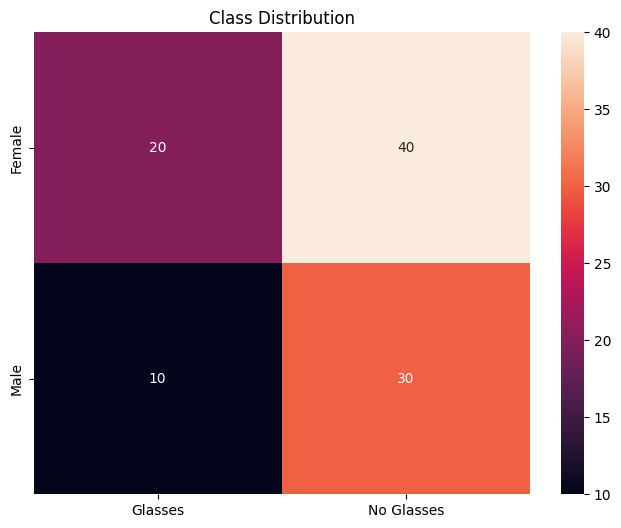

In [ ]:
def class_example():
    # Given numbers
    total = 100
    female = 60
    glasses = 30
    female_glasses = 20

    # Calculate P(F|G)
    p_female_given_glasses = female_glasses / glasses

    print(f"P(F|G) = {female_glasses}/{glasses} = {p_female_given_glasses:.2f}")

    # Visualization
    plt.figure(figsize=(8, 6))
    data = np.array([[20, 40], [10, 30]])  # female_glasses, female_no_glasses, male_glasses, male_no_glasses
    ax = sns.heatmap(data, annot=True, fmt='d',
                    xticklabels=['Glasses', 'No Glasses'],
                    yticklabels=['Female', 'Male'])
    plt.title('Class Distribution')
    plt.show()

class_example()

# **Bayes' Rule and Medical Diagnosis**

Example 6: Disease Testing

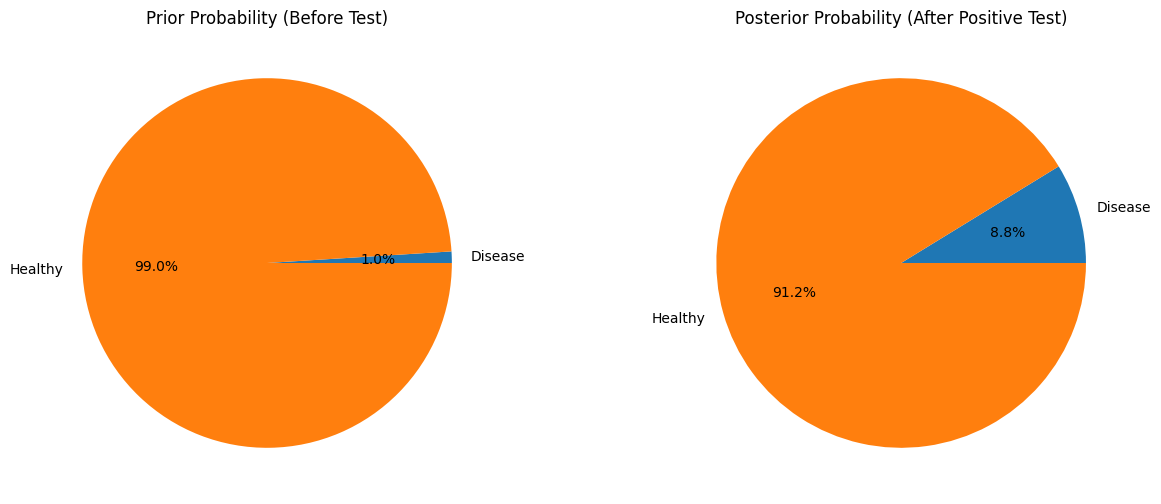

Prior probability of disease: 1.0%
Posterior probability of disease given positive test: 8.8%


In [ ]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def disease_testing_example():
    """
    Demonstrate Bayes' Rule with disease testing example
    """
    # Known probabilities
    p_disease = 0.01        # Prior: 1% of population has disease
    p_pos_given_disease = 0.95  # Likelihood: 95% sensitivity
    p_pos_given_healthy = 0.10  # 10% false positive rate

    # Calculate P(disease|positive)
    p_positive = (p_pos_given_disease * p_disease +
                 p_pos_given_healthy * (1 - p_disease))

    p_disease_given_pos = (p_pos_given_disease * p_disease) / p_positive

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Prior probabilities
    prior = [p_disease, 1-p_disease]
    ax1.pie(prior, labels=['Disease', 'Healthy'], autopct='%1.1f%%')
    ax1.set_title('Prior Probability (Before Test)')

    # Posterior probabilities
    posterior = [p_disease_given_pos, 1-p_disease_given_pos]
    ax2.pie(posterior, labels=['Disease', 'Healthy'], autopct='%1.1f%%')
    ax2.set_title('Posterior Probability (After Positive Test)')

    plt.show()

    print("Prior probability of disease:", f"{p_disease:.1%}")
    print("Posterior probability of disease given positive test:",
          f"{p_disease_given_pos:.1%}")

# Run example
disease_testing_example()

Example 7: Medical Diagnosis Implementation


Diagnosis Probabilities:
Flu: 60.2%
Cold: 30.9%
Covid: 8.9%


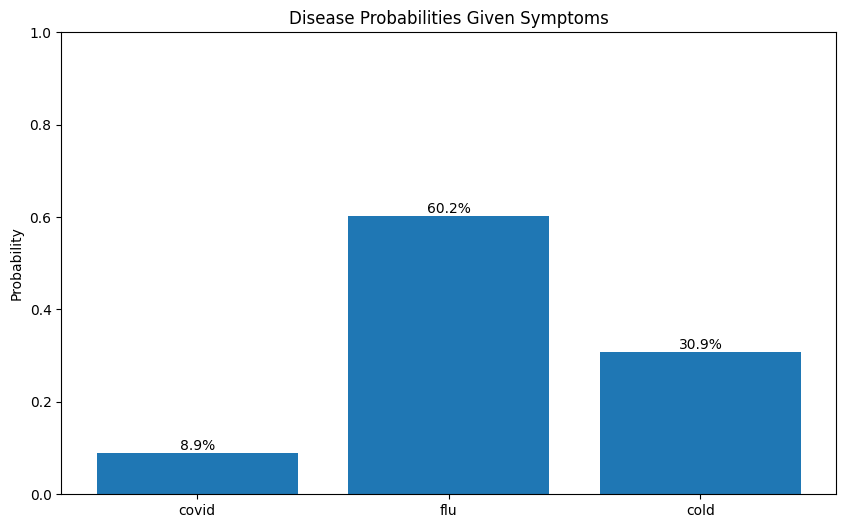

In [ ]:
class BayesianDiagnosis:
    def __init__(self):
        # Disease prior probabilities
        self.disease_priors = {
            'covid': 0.03,   # 3% prevalence
            'flu': 0.08,     # 8% during flu season
            'cold': 0.15     # 15% prevalence
        }

        # Symptom likelihood P(Symptom|Disease)
        self.symptom_likelihoods = {
            'covid': {
                'fever': 0.8,
                'cough': 0.9,
                'fatigue': 0.8,
                'loss_of_taste': 0.6
            },
            'flu': {
                'fever': 0.9,
                'cough': 0.8,
                'fatigue': 0.9,
                'loss_of_taste': 0.1
            },
            'cold': {
                'fever': 0.3,
                'cough': 0.8,
                'fatigue': 0.7,
                'loss_of_taste': 0.05
            }
        }

    def diagnose(self, symptoms):
        """
        Apply Bayes' Rule to calculate disease probabilities
        symptoms: dict of symptom:boolean pairs
        """
        posteriors = {}

        for disease in self.disease_priors:
            # Start with prior
            posterior = self.disease_priors[disease]

            # Multiply by likelihood of each symptom
            for symptom, present in symptoms.items():
                likelihood = self.symptom_likelihoods[disease][symptom]
                if present:
                    posterior *= likelihood
                else:
                    posterior *= (1 - likelihood)

            posteriors[disease] = posterior

        # Normalize
        total = sum(posteriors.values())
        normalized = {d: p/total for d, p in posteriors.items()}

        return normalized

    def plot_diagnosis(self, diagnosis):
        """Visualize diagnosis probabilities"""
        diseases = list(diagnosis.keys())
        probs = list(diagnosis.values())

        plt.figure(figsize=(10, 6))
        bars = plt.bar(diseases, probs)

        # Add probability values on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1%}',
                    ha='center', va='bottom')

        plt.title('Disease Probabilities Given Symptoms')
        plt.ylabel('Probability')
        plt.ylim(0, 1)
        plt.show()

# Example usage
diagnosis_system = BayesianDiagnosis()

# Patient symptoms
patient_symptoms = {
    'fever': True,
    'cough': True,
    'fatigue': True,
    'loss_of_taste': False
}

# Get and display diagnosis
diagnosis = diagnosis_system.diagnose(patient_symptoms)
print("\nDiagnosis Probabilities:")
for disease, prob in sorted(diagnosis.items(), key=lambda x: x[1], reverse=True):
    print(f"{disease.capitalize()}: {prob:.1%}")

# Visualize results
diagnosis_system.plot_diagnosis(diagnosis)

Example 8: Spam Filter

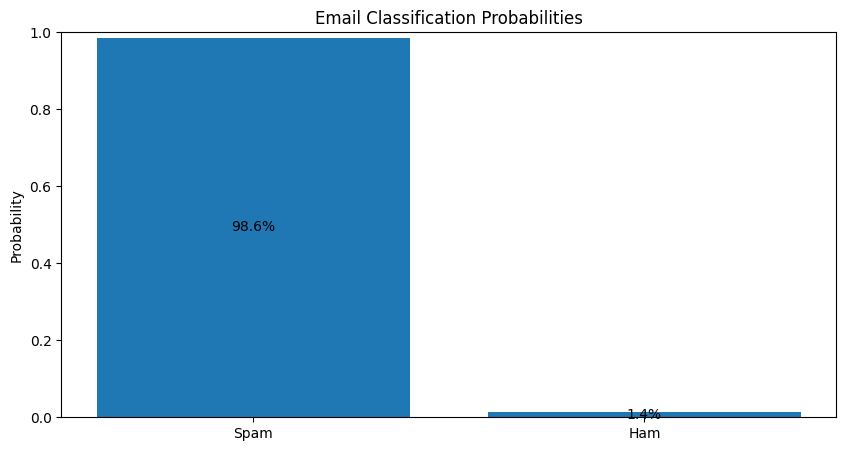


Email contents: money, free, urgent
Probability of spam: 98.6%
Probability of ham: 1.4%


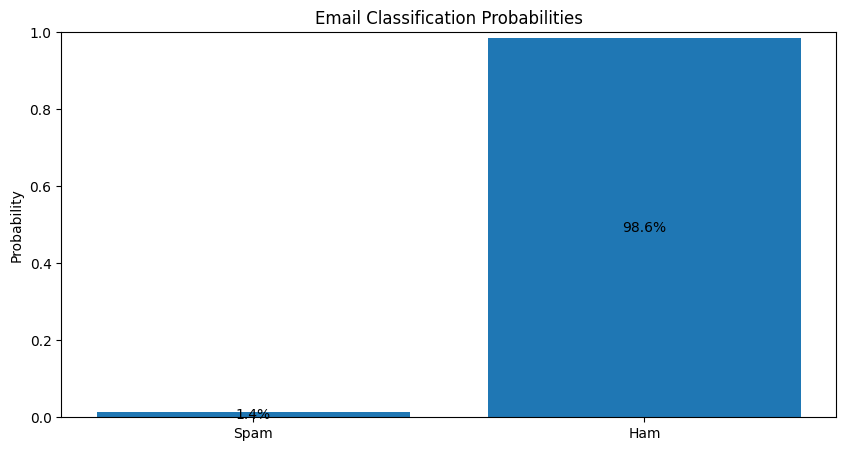


Email contents: meeting, project
Probability of spam: 1.4%
Probability of ham: 98.6%


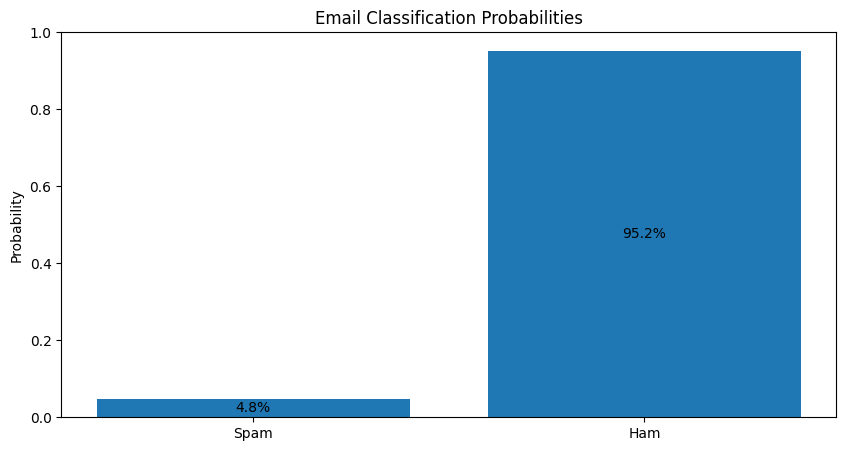


Email contents: free, project, meeting
Probability of spam: 4.8%
Probability of ham: 95.2%


In [ ]:
class BayesSpamFilter:
    def __init__(self):
        # Prior probabilities
        self.p_spam = 0.3  # 30% emails are spam

        # Word likelihoods P(word|category)
        self.word_likelihoods = {
            'spam': {
                'money': 0.8,
                'free': 0.7,
                'urgent': 0.6,
                'meeting': 0.1,
                'project': 0.1
            },
            'ham': {
                'money': 0.1,
                'free': 0.2,
                'urgent': 0.1,
                'meeting': 0.6,
                'project': 0.5
            }
        }

    def classify_email(self, words):
        """Apply Bayes' Rule to classify email"""
        # Start with prior probabilities
        p_spam_given_words = np.log(self.p_spam)
        p_ham_given_words = np.log(1 - self.p_spam)

        # Multiply by likelihood of each word
        for word in words:
            if word in self.word_likelihoods['spam']:
                p_spam_given_words += np.log(self.word_likelihoods['spam'][word])
                p_ham_given_words += np.log(self.word_likelihoods['ham'][word])

        # Convert from log space
        p_spam_given_words = np.exp(p_spam_given_words)
        p_ham_given_words = np.exp(p_ham_given_words)

        # Normalize
        total = p_spam_given_words + p_ham_given_words
        p_spam_given_words /= total
        p_ham_given_words /= total

        return {
            'spam': p_spam_given_words,
            'ham': p_ham_given_words
        }

    def visualize_classification(self, words):
        """Visualize classification results"""
        result = self.classify_email(words)

        plt.figure(figsize=(10, 5))
        probabilities = [result['spam'], result['ham']]
        labels = ['Spam', 'Ham']

        plt.bar(labels, probabilities)
        plt.title('Email Classification Probabilities')
        plt.ylabel('Probability')
        plt.ylim(0, 1)

        # Add probability labels
        for i, prob in enumerate(probabilities):
            plt.text(i, prob/2, f'{prob:.1%}',
                    ha='center', va='center')

        plt.show()

        print(f"\nEmail contents: {', '.join(words)}")
        print(f"Probability of spam: {result['spam']:.1%}")
        print(f"Probability of ham: {result['ham']:.1%}")

# Example usage
spam_filter = BayesSpamFilter()

# Test different types of emails
test_emails = [
    ['money', 'free', 'urgent'],
    ['meeting', 'project'],
    ['free', 'project', 'meeting']
]

for email in test_emails:
    spam_filter.visualize_classification(email)

# **Gaussian Distribution**

Example 9: Gaussian (Normal) Distribution

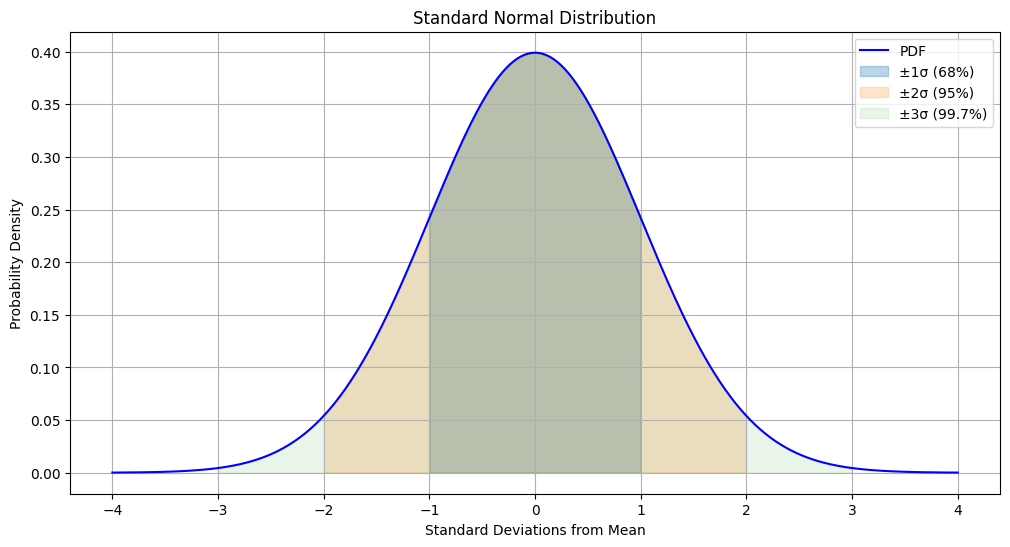

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def visualize_gaussian():
    """Demonstrate properties of Gaussian distribution"""
    # Create data points
    x = np.linspace(-4, 4, 1000)
    mu = 0
    sigma = 1

    # Calculate PDF
    pdf = stats.norm.pdf(x, mu, sigma)

    # Create visualization
    plt.figure(figsize=(12, 6))
    plt.plot(x, pdf, 'b-', label='PDF')

    # Shade regions for standard deviations
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    alphas = [0.3, 0.2, 0.1]
    labels = ['68%', '95%', '99.7%']

    for i, (color, alpha, label) in enumerate(zip(colors, alphas, labels)):
        sigma_range = i + 1
        mask = (x >= -sigma_range) & (x <= sigma_range)
        plt.fill_between(x[mask], pdf[mask], color=color, alpha=alpha,
                        label=f'±{sigma_range}σ ({label})')

    plt.title('Standard Normal Distribution')
    plt.xlabel('Standard Deviations from Mean')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_gaussian()

Example 10: Stock Market Analysis Implementation

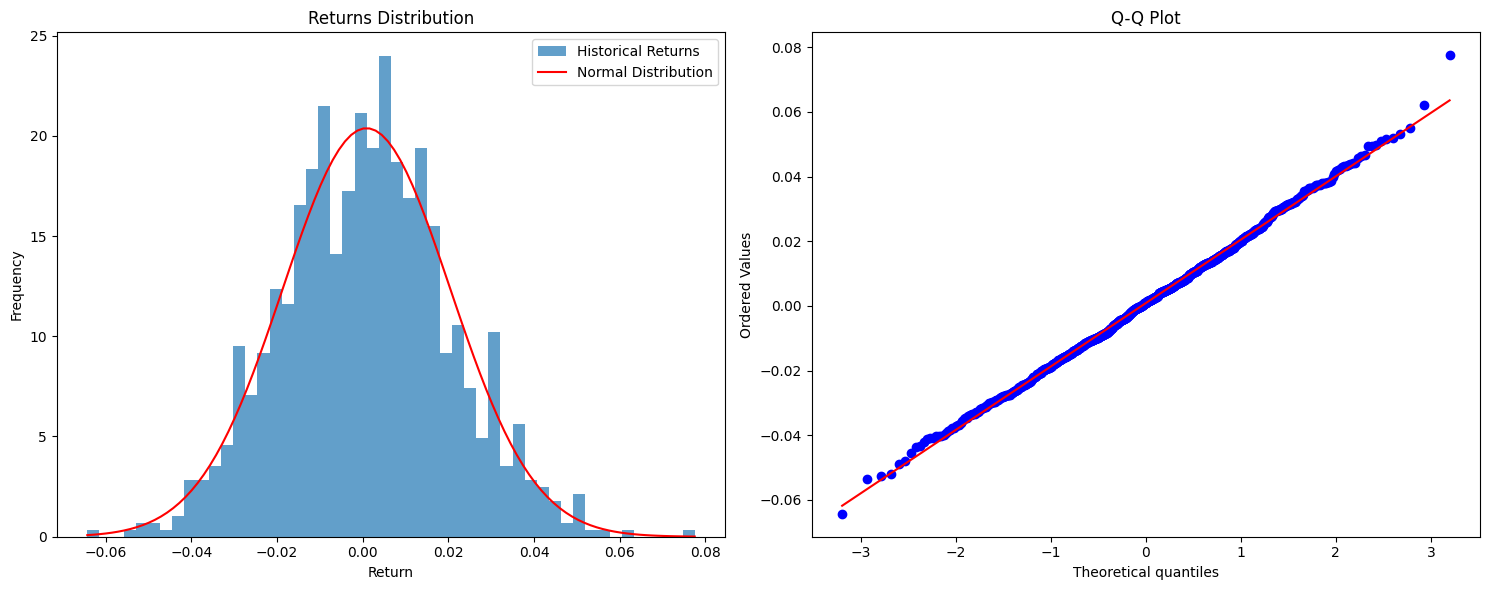


Stock Analysis Metrics:
Daily Mean Return: 0.09%
Daily Volatility: 1.96%
Annual Return: 22.34%
Annual Volatility: 31.07%
Sharpe Ratio: 0.72
95% VaR: 3.13%
Expected Shortfall: -4.13%


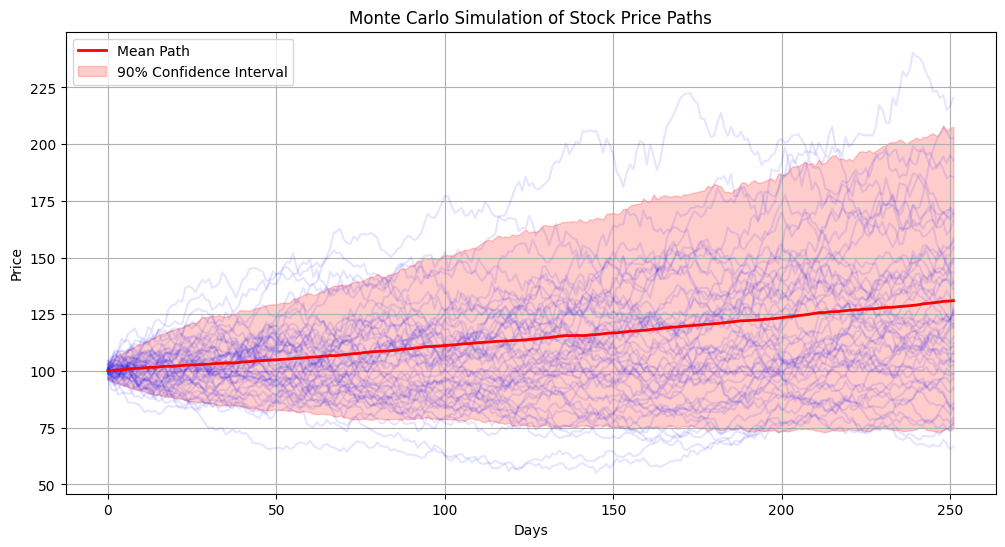

In [ ]:
class StockAnalyzer:
    def __init__(self, returns):
        """
        Initialize with array of historical returns
        """
        self.returns = returns
        self.mean = np.mean(returns)
        self.std = np.std(returns)

    def analyze_distribution(self):
        """Analyze returns distribution"""
        # Create plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Histogram of returns
        ax1.hist(self.returns, bins=50, density=True, alpha=0.7,
                label='Historical Returns')

        # Add theoretical normal distribution
        x = np.linspace(min(self.returns), max(self.returns), 100)
        pdf = stats.norm.pdf(x, self.mean, self.std)
        ax1.plot(x, pdf, 'r-', label='Normal Distribution')
        ax1.set_title('Returns Distribution')
        ax1.set_xlabel('Return')
        ax1.set_ylabel('Frequency')
        ax1.legend()

        # Q-Q plot
        stats.probplot(self.returns, dist="norm", plot=ax2)
        ax2.set_title('Q-Q Plot')

        plt.tight_layout()
        plt.show()

    def calculate_metrics(self, confidence_level=0.95):
        """Calculate key risk metrics"""
        # Value at Risk
        var = -stats.norm.ppf(1 - confidence_level,
                            self.mean,
                            self.std)

        # Expected Shortfall (CVaR)
        z_score = stats.norm.ppf(1 - confidence_level)
        es = -(self.mean + self.std *
               stats.norm.pdf(z_score) / (1 - confidence_level))

        # Annualized metrics (assuming daily returns)
        annual_return = self.mean * 252
        annual_vol = self.std * np.sqrt(252)
        sharpe_ratio = annual_return / annual_vol

        return {
            'mean_return': self.mean,
            'volatility': self.std,
            'var': var,
            'expected_shortfall': es,
            'annual_return': annual_return,
            'annual_vol': annual_vol,
            'sharpe_ratio': sharpe_ratio
        }

    def simulate_future_paths(self, days=252, paths=1000):
        """Monte Carlo simulation of future prices"""
        # Generate random returns
        returns = np.random.normal(
            self.mean,
            self.std,
            (paths, days)
        )

        # Calculate price paths (starting at 100)
        prices = 100 * np.exp(np.cumsum(returns, axis=1))

        # Plot paths
        plt.figure(figsize=(12, 6))

        # Plot sample of paths
        for i in range(min(50, paths)):
            plt.plot(prices[i], alpha=0.1, color='blue')

        # Plot mean path and confidence intervals
        mean_path = np.mean(prices, axis=0)
        percentile_5 = np.percentile(prices, 5, axis=0)
        percentile_95 = np.percentile(prices, 95, axis=0)

        plt.plot(mean_path, 'r-', label='Mean Path', linewidth=2)
        plt.fill_between(range(days), percentile_5, percentile_95,
                        alpha=0.2, color='red',
                        label='90% Confidence Interval')

        plt.title('Monte Carlo Simulation of Stock Price Paths')
        plt.xlabel('Days')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.show()

# Example usage
# Generate sample returns (normally distributed)
np.random.seed(42)
returns = np.random.normal(0.0005, 0.02, 1000)  # μ=5bps, σ=2%

# Create analyzer
analyzer = StockAnalyzer(returns)

# Analyze distribution
analyzer.analyze_distribution()

# Calculate metrics
metrics = analyzer.calculate_metrics()
print("\nStock Analysis Metrics:")
print(f"Daily Mean Return: {metrics['mean_return']:.2%}")
print(f"Daily Volatility: {metrics['volatility']:.2%}")
print(f"Annual Return: {metrics['annual_return']:.2%}")
print(f"Annual Volatility: {metrics['annual_vol']:.2%}")
print(f"Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
print(f"95% VaR: {metrics['var']:.2%}")
print(f"Expected Shortfall: {metrics['expected_shortfall']:.2%}")

# Simulate future paths
analyzer.simulate_future_paths()